In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading, cleaning, floor-plan constants and the time layer (service day, turn gaps,
# occupancy) all live in artemis.py so this notebook and any report generator share one
# pipeline. Editing a cleaning rule there changes it everywhere.
import artemis

In [2]:
# All the cleaning that used to live in this cell now lives in artemis.load_orders() --
# duplicate-chunk removal, numeric coercion, Amount > 0, the implausible-guest-count cut and
# the BD4 exclusion, unchanged. See artemis.py for the reasoning behind each rule.
#
# Two things are new. Full datetimes are preserved as Opened_DT / Closed_DT / Paid_DT (the
# display cells below overwrite Opened/Closed with time-only strings, which used to destroy
# the date and made any time-of-night analysis impossible). And every order gets a
# Service_Date: a Friday that runs to 1:30am now counts as Friday rather than spilling into
# Saturday.
df = artemis.load_orders('OrderDetails_2026_01_15-2026_07_15.csv')
df.head(10)

Exact duplicate rows from overlapping export chunks: 20
Excluded 1 row(s) with implausible guest counts (> 20).
Excluded 22 row(s) from BD4 (retired table, no longer in service).
Loaded 6233 orders, 157 service days (2026-01-15 to 2026-07-15).


,Opened,# of Guests,Table,Discount Amount,Amount,Tip,Gratuity,Total,Closed,Duration (Opened to Paid),...,Capacity_Min,Capacity_Max,Seating_Unit,Unit_Capacity,Likely_Combined_Booking,Exceeds_Solo_Capacity,Order_Type,Service_Date,Service_DOW,Clock_Minutes
0,1/15/26 4:05 PM,2,O3,0.0,94.0,30.0,0.0,132.57,1/15/26 5:25 PM,1:14:12,...,2.0,2.0,O3,2.0,False,False,Seated,2026-01-15,Thursday,965.0
1,1/15/26 4:24 PM,2,O6,0.0,127.0,0.0,0.0,138.62,1/15/26 6:10 PM,1:45:53,...,2.0,2.0,O6,2.0,False,False,Seated,2026-01-15,Thursday,984.0
2,1/15/26 4:52 PM,2,B7,0.0,130.0,0.0,0.0,141.86,1/15/26 6:54 PM,2:02:29,...,1.0,1.0,B7,1.0,True,True,Seated,2026-01-15,Thursday,1012.0
3,1/15/26 4:58 PM,1,B12,0.0,57.0,0.0,0.0,62.22,1/15/26 5:27 PM,0:29:35,...,1.0,1.0,B12,1.0,False,False,Seated,2026-01-15,Thursday,1018.0
4,1/15/26 5:34 PM,2,O2,0.0,133.0,0.0,0.0,145.16,1/15/26 7:17 PM,1:43:42,...,2.0,2.0,O1+O2,5.0,False,False,Seated,2026-01-15,Thursday,1054.0
5,1/15/26 5:41 PM,4,O5,0.0,119.0,23.8,0.0,153.63,1/15/26 7:14 PM,1:23:01,...,2.0,2.0,O4+O5,4.0,False,True,Seated,2026-01-15,Thursday,1061.0
6,1/15/26 5:25 PM,1,B4,0.0,10.0,0.0,0.0,10.92,1/15/26 5:43 PM,0:17:52,...,1.0,1.0,B4,1.0,False,False,Seated,2026-01-15,Thursday,1045.0
7,1/15/26 5:40 PM,4,O9,0.0,297.0,60.0,0.0,384.15,1/15/26 7:40 PM,1:38:20,...,2.0,2.0,O9+O10,4.0,False,True,Seated,2026-01-15,Thursday,1060.0
8,1/15/26 5:57 PM,2,B12,0.0,51.0,5.0,0.0,60.66,1/16/26 12:56 AM,1:11:51,...,1.0,1.0,B12,1.0,True,True,Seated,2026-01-15,Thursday,1077.0
9,1/15/26 10:33 PM,1,NaN,0.0,88.0,0.0,0.0,96.03,1/16/26 1:18 AM,0:02:11,...,NaN,NaN,NaN,NaN,False,False,To-Go,2026-01-15,Thursday,1353.0


In [3]:
df['Amount'].sort_values(ascending=False)


10      5127.09
3509    4704.00
704     2400.00
5766    2298.85
5564    2200.00
         ...   
921        3.00
583        1.00
3508       1.00
6175       0.01
5146       0.01
Name: Amount, Length: 6233, dtype: float64

In [4]:
# get_section() moved to artemis.py; df['Section'] is already assigned by load_orders().
#
# What's new here: every order is now labelled Seated / Event-Catering / To-Go. Previously
# anything without a table fell through the Duration >= 15 floor below and disappeared from the
# analysis entirely -- that was ~$104K of real revenue vanishing silently. These aren't seated
# tables so they still don't belong in per-seat VPCPM/TPCPM, but they shouldn't be invisible.
#
# The split is by check size, not time of day: untabled orders happen across the whole operating
# day, but a $2,200 untabled check is a catering booking whatever hour it was rung in, and a $40
# one is a pickup. Durations on untabled rows are meaningless (they range up to 18 days) because
# nobody was sitting anywhere.
order_types = (
    df.groupby('Order_Type')
      .agg(**{'Orders': ('Amount', 'count'), 'Revenue ($)': ('Amount', 'sum')})
)
order_types['Revenue Share %'] = (100 * order_types['Revenue ($)'] / order_types['Revenue ($)'].sum()).round(1)
order_types.round(2)

,Orders,Revenue ($),Revenue Share %
Order_Type,,,
Event-Catering,80,85015.14,10.7
Seated,5973,693309.01,86.9
To-Go,180,19173.40,2.4


In [5]:
# Duration now comes from artemis.load_orders() -- it parses Toast's own
# 'Duration (Opened to Paid)' rather than differencing Closed - Opened, since Closed frequently
# reflects a late/batch POS close-out rather than actual guest departure.
#
# How much does the Duration >= 15min floor censor each section? Bar is walk-up/quick-turnover,
# so this filter is expected to drop a disproportionate share of Bar rows -- worth knowing before
# trusting any section's stats, especially Bar's (see the context-only summary at the end).
# Unknown/To-Go loses two thirds of its rows here, which is exactly the revenue the Order_Type
# split above now keeps visible.
df, drop_summary = artemis.apply_duration_floor(df)
drop_summary

,Before,After,Dropped,Drop %
Section,,,,
Unknown/To-Go,260,87,173,66.5
Bar,2463,1965,498,20.2
Black Duck,552,545,7,1.3
Open Lounge,2530,2508,22,0.9
Evangeline,428,425,3,0.7


In [6]:
# Display-only formatting. Overwriting Opened/Closed with time-only strings is now safe:
# the real timestamps live on in Opened_DT / Closed_DT / Paid_DT, and everything time-based
# reads those instead.
df.insert(0, 'Date', df['Opened_DT'].dt.strftime('%m/%d/%y'))
df['Opened'] = df['Opened_DT'].dt.strftime('%I:%M %p')
df['Closed'] = df['Closed_DT'].dt.strftime('%I:%M %p')

df.head(10)

,Date,Opened,# of Guests,Table,Discount Amount,Amount,Tip,Gratuity,Total,Closed,...,Capacity_Min,Capacity_Max,Seating_Unit,Unit_Capacity,Likely_Combined_Booking,Exceeds_Solo_Capacity,Order_Type,Service_Date,Service_DOW,Clock_Minutes
0,01/15/26,04:05 PM,2,O3,0.0,94.0,30.0,0.0,132.57,05:25 PM,...,2.0,2.0,O3,2.0,False,False,Seated,2026-01-15,Thursday,965.0
1,01/15/26,04:24 PM,2,O6,0.0,127.0,0.0,0.0,138.62,06:10 PM,...,2.0,2.0,O6,2.0,False,False,Seated,2026-01-15,Thursday,984.0
2,01/15/26,04:52 PM,2,B7,0.0,130.0,0.0,0.0,141.86,06:54 PM,...,1.0,1.0,B7,1.0,True,True,Seated,2026-01-15,Thursday,1012.0
3,01/15/26,04:58 PM,1,B12,0.0,57.0,0.0,0.0,62.22,05:27 PM,...,1.0,1.0,B12,1.0,False,False,Seated,2026-01-15,Thursday,1018.0
4,01/15/26,05:34 PM,2,O2,0.0,133.0,0.0,0.0,145.16,07:17 PM,...,2.0,2.0,O1+O2,5.0,False,False,Seated,2026-01-15,Thursday,1054.0
5,01/15/26,05:41 PM,4,O5,0.0,119.0,23.8,0.0,153.63,07:14 PM,...,2.0,2.0,O4+O5,4.0,False,True,Seated,2026-01-15,Thursday,1061.0
6,01/15/26,05:25 PM,1,B4,0.0,10.0,0.0,0.0,10.92,05:43 PM,...,1.0,1.0,B4,1.0,False,False,Seated,2026-01-15,Thursday,1045.0
7,01/15/26,05:40 PM,4,O9,0.0,297.0,60.0,0.0,384.15,07:40 PM,...,2.0,2.0,O9+O10,4.0,False,True,Seated,2026-01-15,Thursday,1060.0
8,01/15/26,05:57 PM,2,B12,0.0,51.0,5.0,0.0,60.66,12:56 AM,...,1.0,1.0,B12,1.0,True,True,Seated,2026-01-15,Thursday,1077.0
13,01/16/26,04:11 PM,2,B11,0.0,262.0,0.0,0.0,285.96,12:35 AM,...,1.0,1.0,B11,1.0,True,True,Seated,2026-01-16,Friday,971.0


# Value per Person per 15 Minutes


In [7]:
# VPCPM is stored on the raw dollar scale for display, plus a log-scale column (LogVPCPM) used
# for the mean/variance math -- $/guest/15min is right-skewed, and a log-normal assumption is
# what makes mean/SEM/shrinkage math valid. Aggregates below are always back-transformed to
# dollars via exp(mean of logs) -- the geometric mean -- rather than shown in raw log units.
df['VPCPM'] = (df['Amount'] / df['# of Guests']) / (df['Duration'] / 15)
df['LogVPCPM'] = np.log(df['VPCPM'])
df[['VPCPM', 'LogVPCPM']].head(10)


,VPCPM,LogVPCPM
0,9.501348,2.251434
1,8.995750,2.196752
2,7.960267,2.074463
3,28.901408,3.363890
4,9.619094,2.263750
5,5.375427,1.681838
6,8.395522,2.127699
7,11.326271,2.427125
8,5.323591,1.672148
13,9.295908,2.229574


In [8]:
# Exclude Unknown/To-Go orders (Table is NaN) from the pooled party-size trend: Duration for these
# reflects a POS timestamp artifact rather than real seated-table turnover -- e.g. a private-event
# check for $7000 miscoded as 1 guest with a 66-second "duration" -- which would otherwise distort
# the party-size-1 bucket below.
seated_df = df[df['Section'] != 'Unknown/To-Go']

geo_mean_vpcpm = np.exp(seated_df.groupby('# of Guests')['LogVPCPM'].mean())
geo_mean_vpcpm.reset_index().rename(columns={'LogVPCPM': 'Geometric Mean VPCPM ($)'})

,# of Guests,Geometric Mean VPCPM ($)
0,1,8.920856
1,2,7.590912
2,3,6.209824
3,4,5.983150
4,5,5.556095
5,6,5.489533
6,7,4.700451
7,8,4.586536
8,9,4.798843
9,10,4.438674


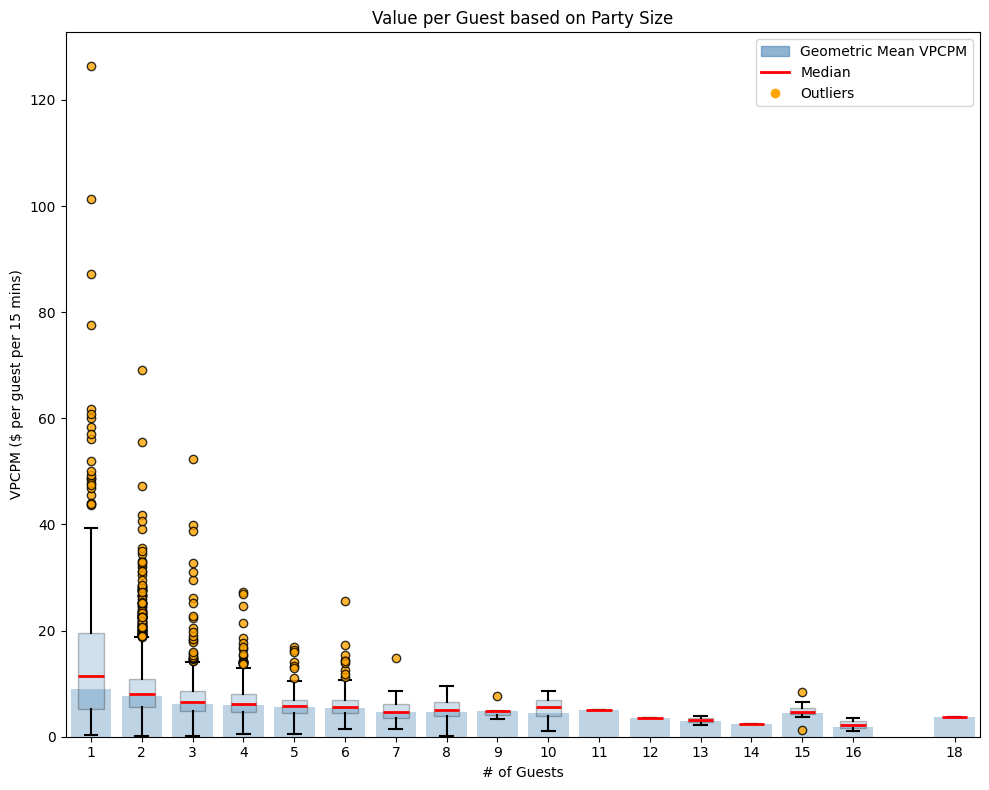

In [9]:
mean_log_vpcpm = seated_df.groupby('# of Guests')['LogVPCPM'].mean()
geo_mean_vpcpm = np.exp(mean_log_vpcpm)
guest_sizes = sorted(seated_df['# of Guests'].unique())
groups = [seated_df[seated_df['# of Guests'] == g]['VPCPM'].values for g in guest_sizes]

fig, ax = plt.subplots(figsize=(10, 8))

ax.bar(geo_mean_vpcpm.index, geo_mean_vpcpm, alpha=0.35, color='steelblue', zorder=1)

ax.boxplot(groups, positions=guest_sizes, widths=0.5,
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.25),
           medianprops=dict(color='red', linewidth=2),
           flierprops=dict(marker='o', markerfacecolor='orange', markersize=6, alpha=0.8),
           whiskerprops=dict(linewidth=1.5),
           capprops=dict(linewidth=1.5),
           zorder=2)

ax.set_xticks(guest_sizes)
ax.set_xlabel('# of Guests')
ax.set_ylabel('VPCPM ($ per guest per 15 mins)')
ax.set_title('Value per Guest based on Party Size')

handles = [
    plt.Rectangle((0, 0), 1, 1, color='steelblue', alpha=0.6),
    plt.Line2D([0], [0], color='red', linewidth=2),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=8),
]
ax.legend(handles, ['Geometric Mean VPCPM', 'Median', 'Outliers'], loc='best')
plt.tight_layout()
plt.show()

## Who Spends More Per Hour? — Descriptive Analysis by Party Size


## Seating Units & Capacity

**The POS table code is not the physical unit.** Black Duck and Evangeline are banquettes subdivided into two codes each, and most Open Lounge tables pair up. When a party takes a whole banquette or a combined pair, Toast records the check against one of its codes — so comparing guest count to that *code's* capacity makes an ordinary booking look like an overflow.

The pairings are confirmed two ways: against Tock, and against the order data itself. If two codes share one banquette, then whenever one hosts a party too large for its own half, the other must be empty — and it is, 92–100% of the time, versus 20–66% for small parties. Non-adjacent control pairs show no such effect.

| Unit | POS codes | Seats |
| --- | --- | --- |
| Black Duck large banquette | `BD3` + `BD5` | 8 |
| Black Duck small banquette | `BD1` + `BD2` | 6 |
| Evangeline pair | `E1` + `E2` | 4 |
| Evangeline large | `E3` | 5–6 |
| Open Lounge combos | `O1`+`O2` (5), `O4`+`O5` (4), `O7`+`O8` (5), `O9`+`O10` (4) | 18 |
| Open Lounge standalone | `O3`, `O6` — never combined | 4 |
| Bar | `B1`–`B12`, one seat each | 12 |

Summing units reproduces the operator's own section totals exactly: **Open Lounge 22, Black Duck 14, Evangeline 10, Bar 12**.

`B13`/`B14` are standing-wait placeholders — used when a guest is served while waiting for a real stool — not physical seats, so they carry no capacity. `BD4` is retired and its historical orders are excluded entirely earlier in the notebook.

`Capacity_Min`/`Capacity_Max` remain on each row as the *solo* range — what a code seats when its partner is in separate use — but the binding constraint is now `Unit_Capacity`.

In [10]:
# SEATING_UNITS and CAPACITY_RANGES both live in artemis.py as the single source of truth, and
# load_orders() has already attached Seating_Unit, Unit_Capacity, Capacity_Min and Capacity_Max.
unit_map = (df[['Table', 'Section', 'Seating_Unit', 'Unit_Capacity', 'Capacity_Min', 'Capacity_Max']]
              .drop_duplicates()
              .sort_values(['Section', 'Seating_Unit', 'Table']))

print('Section seat totals, summed over physical units:')
for section in ['Open Lounge', 'Black Duck', 'Evangeline', 'Bar']:
    units = artemis.section_units(section)
    print(f'  {section:14} {artemis.section_seats(section):3} seats across {len(units):2} units')
print()
unit_map

Section seat totals, summed over physical units:
  Open Lounge     22 seats across  6 units
  Black Duck      14 seats across  2 units
  Evangeline      10 seats across  2 units
  Bar             12 seats across 12 units



,Table,Section,Seating_Unit,Unit_Capacity,Capacity_Min,Capacity_Max
59,B1,Bar,B1,1.0,1.0,1.0
27,B10,Bar,B10,1.0,1.0,1.0
13,B11,Bar,B11,1.0,1.0,1.0
3,B12,Bar,B12,1.0,1.0,1.0
15,B2,Bar,B2,1.0,1.0,1.0
36,B3,Bar,B3,1.0,1.0,1.0
6,B4,Bar,B4,1.0,1.0,1.0
37,B5,Bar,B5,1.0,1.0,1.0
61,B6,Bar,B6,1.0,1.0,1.0
2,B7,Bar,B7,1.0,1.0,1.0


In [11]:
unassigned = df[df['Capacity_Max'].isna() & df['Table'].notna()]
print('Tables with no capacity assigned (excluded from capacity-based analysis):')
print(unassigned['Table'].value_counts())

# Toast records one table code per order. When a party takes a whole banquette or a confirmed
# combo pair, the check lands on one anchor code -- so exceeding that *code's* solo capacity is
# entirely normal and says nothing about the data being wrong.
#
# Exceeding the whole *unit's* capacity is the real signal of a booking that spans units, which
# Toast genuinely cannot reconstruct (a check has exactly one table reference, and combining
# checks moves items onto a single destination check).
#
# The two definitions side by side. The per-code version is what previously made half the room
# look overbooked; it was measuring parties against half a banquette.
compare = (df[df['Section'].isin(artemis.RESERVATION_SECTIONS)]
             .groupby('Section')
             .agg(**{'Orders': ('Amount', 'count'),
                     'Exceeds solo code': ('Exceeds_Solo_Capacity', 'sum'),
                     'Exceeds whole unit': ('Likely_Combined_Booking', 'sum')}))
compare['Solo %'] = (100 * compare['Exceeds solo code'] / compare['Orders']).round(0)
compare['Unit %'] = (100 * compare['Exceeds whole unit'] / compare['Orders']).round(0)
print('\nOverbooking rate, per-code vs per-unit:')
print(compare.to_string())

# Restricted to the reservation sections. The Bar trips this flag on ~78% of its rows too, but
# that is the long-documented 2-guests-on-a-1-seat-stool case -- a routine 2-top, not a booking
# spanning units -- so mixing it in here would misrepresent both.
overbooked = df[df['Likely_Combined_Booking'] & df['Section'].isin(artemis.RESERVATION_SECTIONS)]
print(f'\nReservation-section rows genuinely exceeding their unit ({len(overbooked)}, '
      f'${overbooked["Amount"].sum():,.0f}) -- these really do span multiple units, and stay '
      'excluded from the per-seat analysis below:')
overbooked[['Table', 'Section', 'Seating_Unit', 'Unit_Capacity', '# of Guests', 'Amount']]

Tables with no capacity assigned (excluded from capacity-based analysis):
Table
B14    35
B13    15
Name: count, dtype: int64

Overbooking rate, per-code vs per-unit:
             Orders  Exceeds solo code  Exceeds whole unit  Solo %  Unit %
Section                                                                   
Black Duck      545                269                  48    49.0     9.0
Evangeline      425                114                  29    27.0     7.0
Open Lounge    2508                674                  31    27.0     1.0

Reservation-section rows genuinely exceeding their unit (108, $40,654) -- these really do span multiple units, and stay excluded from the per-seat analysis below:


,Table,Section,Seating_Unit,Unit_Capacity,# of Guests,Amount
167,BD2,Black Duck,BD 6-top banquette,6.0,8,564.0
224,BD2,Black Duck,BD 6-top banquette,6.0,7,324.0
277,O8,Open Lounge,O7+O8,5.0,8,303.0
292,E1,Evangeline,E 2+2 pair,4.0,10,41.0
380,BD2,Black Duck,BD 6-top banquette,6.0,15,840.0
...,...,...,...,...,...,...
6160,E1,Evangeline,E 2+2 pair,4.0,10,710.0
6179,BD3,Black Duck,BD 8-top banquette,8.0,15,1017.0
6200,O5,Open Lounge,O4+O5,4.0,5,124.0
6204,BD1,Black Duck,BD 6-top banquette,6.0,7,663.0


## Bar vs. Table Seating

The bar (12 single-guest stools, no reservations) and the table sections (Black Duck, Evangeline, Open Lounge — where reservations actually happen) serve very different party-size ranges and different business decisions, so VPCPM is plotted separately for each rather than pooled. The reservation-relevant sections get the shrinkage/LOOCV treatment below; Bar gets its own context-only summary further down.


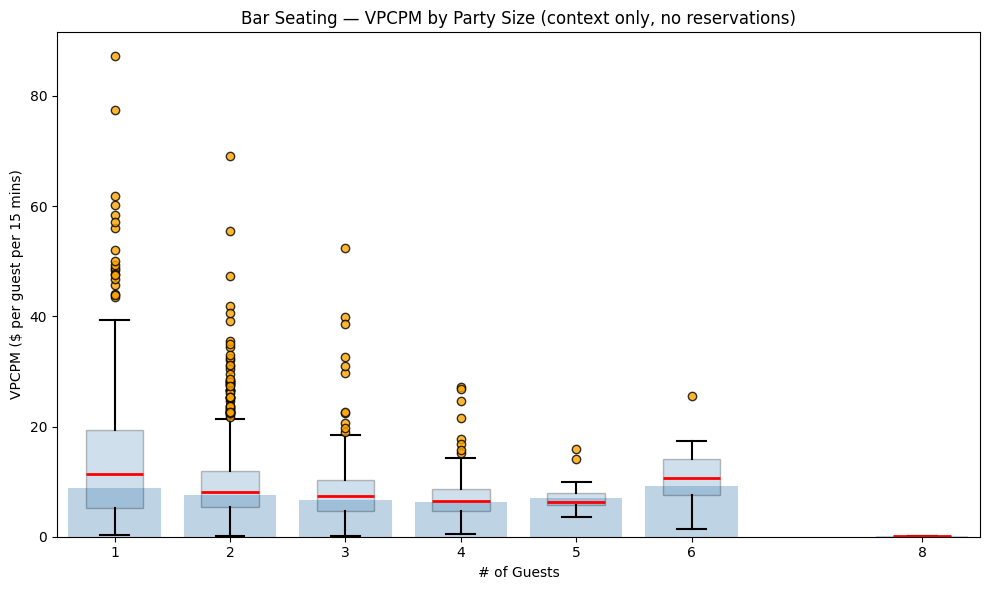

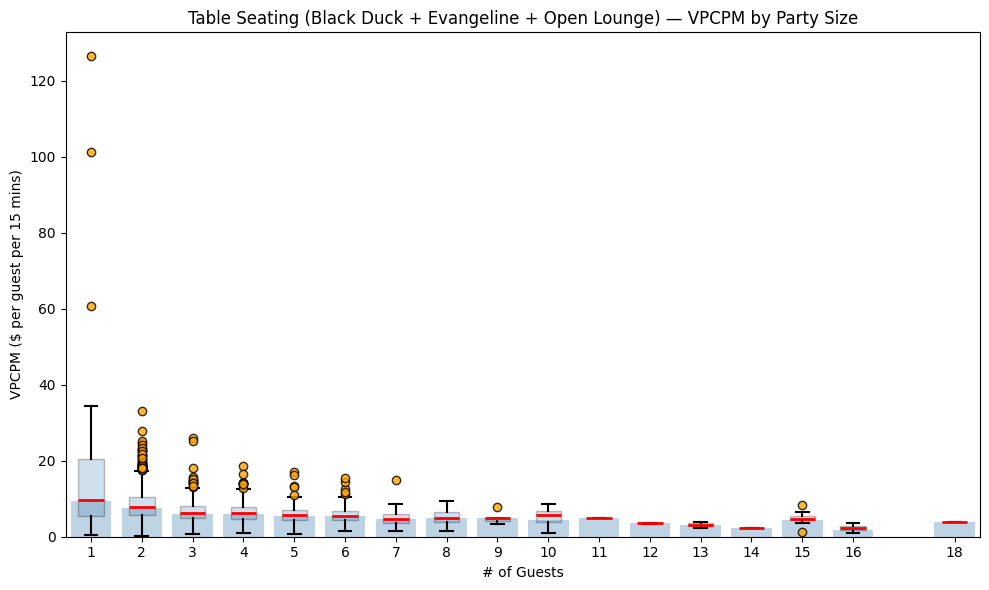

In [12]:
def plot_vpcpm_by_party_size(sub_df, title):
    geo_mean_vpcpm = np.exp(sub_df.groupby('# of Guests')['LogVPCPM'].mean())
    guest_sizes = sorted(sub_df['# of Guests'].unique())
    groups = [sub_df[sub_df['# of Guests'] == g]['VPCPM'].values for g in guest_sizes]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(geo_mean_vpcpm.index, geo_mean_vpcpm, alpha=0.35, color='steelblue', zorder=1)
    ax.boxplot(groups, positions=guest_sizes, widths=0.5,
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.25),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='orange', markersize=6, alpha=0.8),
               whiskerprops=dict(linewidth=1.5),
               capprops=dict(linewidth=1.5),
               zorder=2)
    ax.set_xticks(guest_sizes)
    ax.set_xlabel('# of Guests')
    ax.set_ylabel('VPCPM ($ per guest per 15 mins)')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

bar_df = df[df['Section'] == 'Bar']
table_df = df[df['Section'].isin(['Black Duck', 'Evangeline', 'Open Lounge'])]

plot_vpcpm_by_party_size(bar_df, 'Bar Seating — VPCPM by Party Size (context only, no reservations)')
plot_vpcpm_by_party_size(table_df, 'Table Seating (Black Duck + Evangeline + Open Lounge) — VPCPM by Party Size')


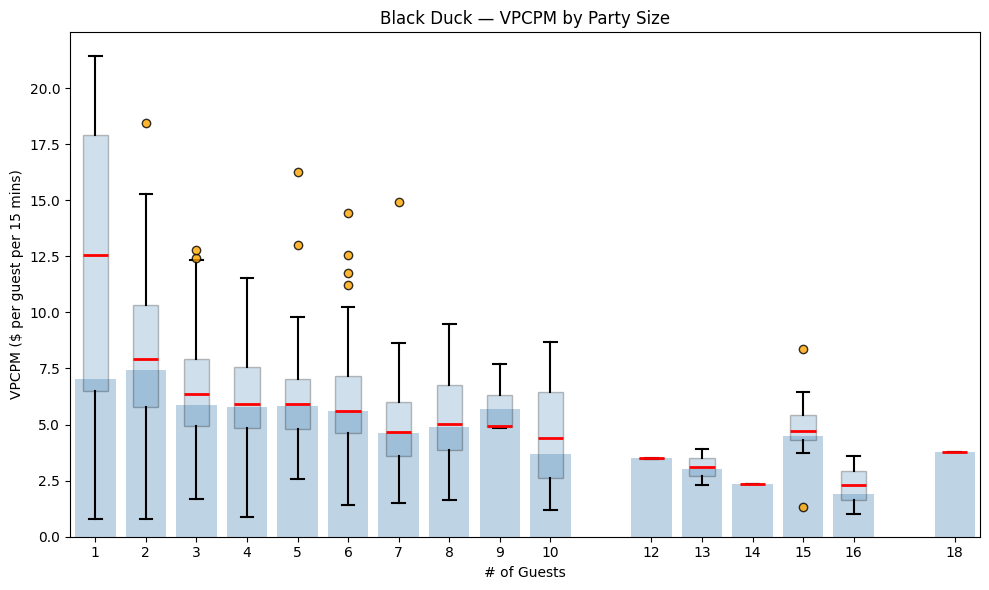

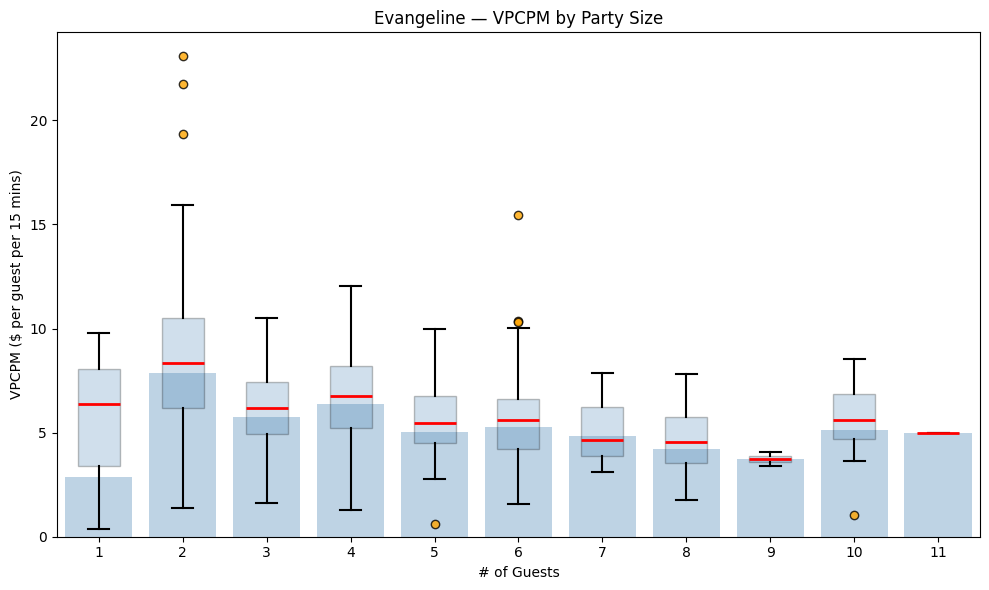

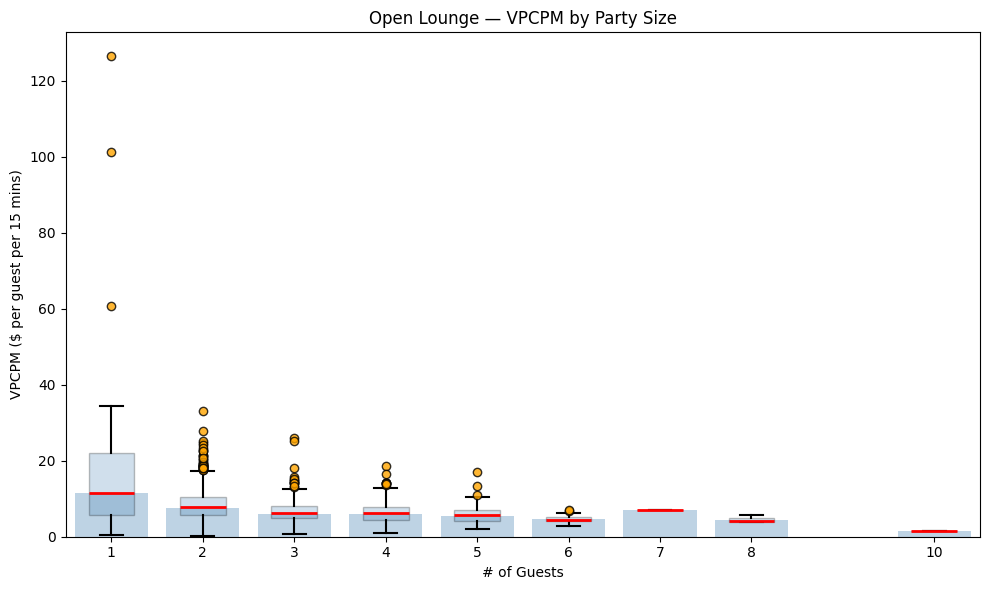

In [13]:
for section in ['Black Duck', 'Evangeline', 'Open Lounge']:
    plot_vpcpm_by_party_size(df[df['Section'] == section], f'{section} — VPCPM by Party Size')


## Table-Level Revenue Rate (TPCPM)

VPCPM normalizes by guest count, which is useful for per-seat comparisons but can obscure how much a table earns in total. **TPCPM** (Total revenue Per table, Per 15 Minutes) = `Amount / (Duration / 15)` answers the capacity-planning question directly: for a table of a given size, does a full party or a smaller one generate more $/15min? TPCPM is already on the raw dollar scale, so it needs no back-transform.


In [14]:
df['TPCPM'] = df['Amount'] / (df['Duration'] / 15)
df['LogTPCPM'] = np.log(df['TPCPM'])  # own log-scale column -- TPCPM has its own skew, distinct from VPCPM's

df.groupby(['Section', '# of Guests'])['TPCPM'].agg(['mean', 'count']).sort_values(by= 'mean', ascending=False).round(2)

mean  count
Section       # of Guests               
Unknown/To-Go 9            120.20      1
              1             76.20     84
Black Duck    15            72.98     11
              18            67.83      1
Bar           6             67.50     11
Unknown/To-Go 3             61.98      1
Evangeline    10            56.55     13
              11            54.72      1
Black Duck    9             52.43      3
Open Lounge   7             49.63      1
Black Duck    10            46.68      4
              12            41.88      2
              8             41.86     66
              13            40.33      2
Bar           5             38.18     12
Evangeline    8             37.39      6
Black Duck    16            36.61      2
Evangeline    7             36.37      3
Open Lounge   8             36.35      4
Black Duck    6             36.28     89
              7             35.25     37
Evangeline    6             33.90    103
              9             33.60      2
Black Duck    14            32.85      1
              5             31.57     35
Bar           4             29.75    117
Open Lounge   5             29.51    110
              6             28.32     15
Evangeline    5             27.98     29
              4             27.22     91
Bar           3             25.59    185
Open Lounge   4             25.55    453
Black Duck    4             24.94    107
Open Lounge   1             22.70     24
              3             20.27    297
Black Duck    3             19.35     52
Evangeline    3             18.76     27
Bar           2             18.68   1224
Evangeline    2             17.24    147
Open Lounge   2             16.96   1603
Black Duck    2             16.35    129
Bar           1             14.39    415
Open Lounge   10            13.79      1
Black Duck    1             11.84      4
Evangeline    1              5.51      3
Unknown/To-Go 2              1.49      1
Bar           8              0.95      1

## Section Summary & Recommendations

Ranking party sizes within each **reservation-relevant** section (Black Duck, Evangeline, Open Lounge — Bar has no reservations to optimize and is covered separately below) by a shrinkage-weighted VPCPM score. **Likely combined-table/event bookings (`Likely_Combined_Booking`) are excluded here** — see the note above and the separate section further down — so this table reflects single-table party economics, not event revenue misattributed to one table. Low-order-count party sizes get pulled toward their section's overall mean; the shrinkage strength `k` is no longer a hand-picked heuristic — it's selected per section via leave-one-out cross-validation (LOOCV), separately for VPCPM (on `LogVPCPM`) and TPCPM (on its own `LogTPCPM`, since TPCPM has its own skew/variance structure), choosing whichever `k` minimizes out-of-sample squared prediction error for that section and metric. Displayed VPCPM/TPCPM figures are back-transformed to dollars (`exp` of the log-scale shrinkage estimate). Party sizes backed by fewer than 10 orders are marked `Thin Sample` — treat those weighted estimates as illustrative, not decision-grade. 95% CIs are paused for now pending a proper significance-testing pass.

In [15]:
def select_k_loocv(section_df, value_col='LogVPCPM', group_col='# of Guests', k_grid=None):
    """Pick the shrinkage weight k that minimizes leave-one-out squared prediction error."""
    if k_grid is None:
        k_grid = np.array([1, 2, 3, 5, 8, 12, 20, 30, 50, 75, 100, 150, 200])

    values = section_df[value_col].to_numpy()
    group_sum = section_df.groupby(group_col)[value_col].transform('sum').to_numpy()
    group_n = section_df.groupby(group_col)[value_col].transform('count').to_numpy()
    n_loo = group_n - 1
    group_mean_loo = np.divide(
        group_sum - values, n_loo,
        out=np.full_like(values, np.nan, dtype=float), where=n_loo > 0,
    )

    section_sum = values.sum()
    section_n = len(values)
    section_mean_loo = (section_sum - values) / (section_n - 1)

    valid = n_loo > 0  # can't leave-one-out a party size backed by a single order
    errors = {}
    for k in k_grid:
        w = n_loo / (n_loo + k)
        pred = w * group_mean_loo + (1 - w) * section_mean_loo
        errors[int(k)] = float(np.sum((values[valid] - pred[valid]) ** 2))

    best_k = min(errors, key=errors.get)
    return best_k, errors

RESERVATION_SECTIONS = artemis.RESERVATION_SECTIONS  # single source of truth in artemis.py
# Likely combined-table/event bookings excluded here too, so k isn't fit to distorted large-party
# noise -- it should reflect single-table party-size variance, which is what it's shrinking.
single_table_df = df[~df['Likely_Combined_Booking']]

selected_k = {}
selected_k_tpcpm = {}
for section in RESERVATION_SECTIONS:
    section_df = single_table_df[single_table_df['Section'] == section]
    k, errors = select_k_loocv(section_df, value_col='LogVPCPM')
    selected_k[section] = k
    # TPCPM gets its own LOOCV-selected k on LogTPCPM -- it has its own skew/variance structure,
    # distinct from VPCPM's, so reusing VPCPM's k here isn't justified.
    k_tpcpm, errors_tpcpm = select_k_loocv(section_df, value_col='LogTPCPM')
    selected_k_tpcpm[section] = k_tpcpm

pd.DataFrame({
    'VPCPM k': pd.Series(selected_k),
    'TPCPM k': pd.Series(selected_k_tpcpm),
})

,VPCPM k,TPCPM k
Black Duck,20,2
Evangeline,20,1
Open Lounge,8,8


In [16]:
res_df = single_table_df[single_table_df['Section'].isin(RESERVATION_SECTIONS)]

summary = (
    res_df.groupby(['Section', '# of Guests'])
      .agg(**{
          'Mean LogVPCPM': ('LogVPCPM', 'mean'),
          'Mean LogTPCPM': ('LogTPCPM', 'mean'),
          'Orders': ('LogVPCPM', 'count'),
      })
      .reset_index()
)

section_means = res_df.groupby('Section')[['LogVPCPM', 'LogTPCPM']].mean()
summary['Section Mean LogVPCPM'] = summary['Section'].map(section_means['LogVPCPM'])
summary['Section Mean LogTPCPM'] = summary['Section'].map(section_means['LogTPCPM'])

# Shrinkage-weighted score: pulls low-order party sizes toward their section's overall mean.
# VPCPM and TPCPM each use their own LOOCV-selected k (see above), computed on their own log scale.
k_vpcpm = summary['Section'].map(selected_k)
k_tpcpm = summary['Section'].map(selected_k_tpcpm)
n = summary['Orders']
summary['Weighted LogVPCPM'] = (n / (n + k_vpcpm)) * summary['Mean LogVPCPM'] + (k_vpcpm / (n + k_vpcpm)) * summary['Section Mean LogVPCPM']
summary['Weighted LogTPCPM'] = (n / (n + k_tpcpm)) * summary['Mean LogTPCPM'] + (k_tpcpm / (n + k_tpcpm)) * summary['Section Mean LogTPCPM']

summary['Mean VPCPM ($)'] = np.exp(summary['Mean LogVPCPM'])
summary['Weighted VPCPM ($)'] = np.exp(summary['Weighted LogVPCPM'])
summary['Mean TPCPM ($)'] = np.exp(summary['Mean LogTPCPM'])
summary['Weighted TPCPM ($)'] = np.exp(summary['Weighted LogTPCPM'])

# Flag party sizes with a thin underlying sample so a single-order estimate isn't mistaken for a
# stable one -- shrinkage still applies, this is just a visibility flag on top of it.
THIN_SAMPLE_THRESHOLD = 10
summary['Thin Sample'] = summary['Orders'] < THIN_SAMPLE_THRESHOLD

display_cols = ['Section', '# of Guests', 'Mean VPCPM ($)', 'Weighted VPCPM ($)', 'Mean TPCPM ($)', 'Weighted TPCPM ($)', 'Orders', 'Thin Sample']
(
    summary[display_cols]
        .sort_values(['Section', 'Weighted VPCPM ($)'], ascending=[True, False])
        .round(2)
)

,Section,# of Guests,Mean VPCPM ($),Weighted VPCPM ($),Mean TPCPM ($),Weighted TPCPM ($),Orders,Thin Sample
1,Black Duck,2,7.42,7.21,14.84,14.94,129,False
0,Black Duck,1,7.02,6.13,7.02,10.47,4,True
2,Black Duck,3,5.89,5.91,17.66,17.84,52,False
4,Black Duck,5,5.82,5.87,29.11,28.76,35,False
3,Black Duck,4,5.78,5.81,23.12,23.12,107,False
5,Black Duck,6,5.60,5.67,33.60,33.33,89,False
6,Black Duck,7,4.51,5.16,31.60,30.81,22,False
7,Black Duck,8,4.88,5.13,39.00,38.35,59,False
9,Evangeline,2,7.88,7.68,15.76,15.80,147,False
11,Evangeline,4,6.39,6.39,25.55,25.50,91,False


## Large Party / Combined-Table Bookings — Mostly Resolved

**This was the repo's largest open issue, and modelling seating units has largely closed it.** The problem was never that half the room was overbooked; it was that guest counts were being compared against *half a banquette*. Measuring against the whole physical unit instead:

| Section | Exceeds solo code | Exceeds whole unit |
| --- | --- | --- |
| Black Duck | 49% | **9%** |
| Evangeline | 27% | **7%** |
| Open Lounge | 27% | **1%** |

(The original figures quoted in earlier versions were higher still — Black Duck 60% — because `BD1` and `BD5` were modelled as 2-seaters.)

**What remains is real.** A residual ~100 reservation-section rows genuinely exceed their unit's capacity — median 8 guests, up to 18 — and those are true multi-unit bookings that Toast cannot reconstruct, since a check carries exactly one table reference and combining checks moves items onto a single destination check. They stay excluded from per-seat economics and are summarised descriptively below so the revenue isn't dropped from view.

The remaining fix is unchanged in kind but much smaller in scope: a Toast floor-plan combo configuration, or a staff tagging convention at merge time, would recover the last few percent.

In [17]:
# Restricted to the reservation-relevant sections -- Bar's `Likely_Combined_Booking` rows are a
# different, already-documented phenomenon (routine 2-guest checks on a 1-seat stool, not events;
# see the earlier overbooking discussion), so including them here would mislabel them as events.
combined_bookings = df[df['Likely_Combined_Booking'] & df['Section'].isin(RESERVATION_SECTIONS)]

combined_summary = (
    combined_bookings.groupby('Section')
      .agg(**{
          'Total Revenue ($)': ('Amount', 'sum'),
          'Orders': ('Amount', 'count'),
          'Median Guests': ('# of Guests', 'median'),
          'Max Guests': ('# of Guests', 'max'),
      })
      .reset_index()
      .sort_values('Total Revenue ($)', ascending=False)
      .round(2)
)
combined_summary


,Section,Total Revenue ($),Orders,Median Guests,Max Guests
0,Black Duck,24241.45,48,9.0,18
1,Evangeline,11244.90,29,9.0,11
2,Open Lounge,5167.80,31,6.0,10


## Bar — Revenue Reference (No Reservations)

Bar seats aren't reservable, so there's no seating decision to optimize here — this is a descriptive record only (e.g. "which party size brings in the most revenue at the bar"), not a recommendation. Note the `Duration >= 15min` filter (see the drop-rate table earlier in the notebook) removes a disproportionate share of Bar orders, so treat these figures as biased toward slower bar visits.


In [18]:
bar_df = df[df['Section'] == 'Bar']  # re-sliced here since TPCPM was added to df after the earlier bar_df/table_df split

bar_summary = (
    bar_df.groupby('# of Guests')
      .agg(**{
          'Mean VPCPM ($)': ('LogVPCPM', lambda s: np.exp(s.mean())),
          'Mean TPCPM': ('TPCPM', 'mean'),
          'Orders': ('LogVPCPM', 'count'),
      })
      .reset_index()
      .sort_values('Mean VPCPM ($)', ascending=False)
      .round(2)
)
bar_summary['Thin Sample'] = bar_summary['Orders'] < 10  # e.g. party-size 8 here is a single order -- treat as anecdote, not signal
bar_summary

,# of Guests,Mean VPCPM ($),Mean TPCPM,Orders,Thin Sample
5,6,9.12,67.50,11,False
0,1,8.89,14.39,415,False
1,2,7.48,18.68,1224,False
4,5,6.95,38.18,12,False
2,3,6.59,25.59,185,False
3,4,6.26,29.75,117,False
6,8,0.12,0.95,1,True


# Turn Times & Table Utilization

Everything above looks at one order at a time, which cannot show a table sitting empty between two parties. This section reconstructs the night: how long each table stayed idle between seatings, and how full the room was at the time.

**The headline going in** was that idle time between parties is the big recoverable lever — the median gap is ~31 minutes, and on the highest-revenue Friday in the dataset `BD3` sat empty for 296 consecutive minutes. **The analysis below does not support that conclusion**, and the reason it doesn't is the most useful thing in this notebook.

In [19]:
# Rebuild the time layer on the cleaned frame. add_turn_gaps measures, for each table within a
# single service night, how long it sat empty between one party paying and the next sitting down.
# build_occupancy records which tables were full in each 15-minute slot.
seated = artemis.add_turn_gaps(df)
occ = artemis.build_occupancy(seated)

res = seated[seated['Section'].isin(artemis.RESERVATION_SECTIONS)].copy()
NT = artemis.RESERVATION_TABLE_COUNT   # 17 real reservation-section tables (BD4 retired)
NIGHTS = res['Service_Date'].nunique()
DOW_ORDER = ['Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

gaps = res[res['Turn_Gap'].notna()].copy()
gaps['Paid_Hour'] = gaps['Paid_DT'].dt.hour

print(f'{len(gaps)} measured turns across {NIGHTS} nights and {NT} tables')
print(f'median gap {gaps["Turn_Gap"].median():.1f} min, mean {gaps["Turn_Gap"].mean():.1f} min\n')

by_dow = gaps.groupby('Service_DOW')['Turn_Gap'].agg(['count', 'median', 'mean']).reindex(DOW_ORDER)
by_hour = gaps.groupby('Paid_Hour')['Turn_Gap'].agg(['count', 'median', 'mean'])
by_hour = by_hour[by_hour['count'] >= 20]
turns_per_night = (res.groupby(['Service_Date', 'Service_DOW', 'Table']).size()
                     .reset_index(name='turns').groupby('Service_DOW')['turns'].mean().reindex(DOW_ORDER))

summary_dow = by_dow.round(1)
summary_dow['turns per table-night'] = turns_per_night.round(2)
print('Gap by day of week:'); print(summary_dow.to_string())
print('\nGap by the hour the table came free:'); print(by_hour.round(1).to_string())

1718 measured turns across 153 nights and 17 tables
median gap 30.3 min, mean 46.9 min

Gap by day of week:
             count  median  mean  turns per table-night
Service_DOW                                            
Tuesday         68    59.6  70.8                   1.33
Wednesday      114    43.7  54.5                   1.52
Thursday       152    35.2  49.7                   1.59
Friday         625    28.3  42.4                   2.60
Saturday       648    26.6  42.8                   2.85
Sunday         111    57.4  70.8                   1.65

Gap by the hour the table came free:
           count  median  mean
Paid_Hour                     
17           144    60.7  75.8
18           267    46.1  68.1
19           325    32.0  46.1
20           356    31.7  47.2
21           317    24.9  32.6
22           210    22.5  28.0
23            76    19.4  20.5


In [20]:
# Is any individual table chronically badly turned? If a specific table is the problem, that's a
# host-stand fix. Restricted to tables with >= 30 measured turns so the medians mean something.
per_table = (res.groupby(['Section', 'Table'])
               .agg(**{'Turns': ('Turn_Gap', 'count'),
                       'Median Gap': ('Turn_Gap', 'median'),
                       'Median Duration': ('Duration', 'median'),
                       'Orders': ('Amount', 'count'),
                       'Revenue ($)': ('Amount', 'sum')}))
per_table = per_table[per_table['Turns'] >= 30]
section_median = res.groupby('Section')['Turn_Gap'].median()
per_table['vs Section (min)'] = (per_table['Median Gap']
                                 - per_table.index.get_level_values('Section').map(section_median))

print('Spread between best and worst table: '
      f'{per_table["Median Gap"].max() - per_table["Median Gap"].min():.1f} min\n')
per_table.sort_values('vs Section (min)', ascending=False).round(1)

Spread between best and worst table: 13.4 min



Turns  Median Gap  Median Duration  Orders  Revenue ($)  \
Section     Table                                                            
Black Duck  BD5       47        38.7             94.9     112      26975.2   
Open Lounge O2        55        36.8             91.4     133      15489.0   
Evangeline  E2        62        30.6             88.8     117      18675.7   
Open Lounge O6       227        34.2             85.7     384      37941.8   
            O4       110        34.2             98.1     238      29268.7   
            O5       104        33.2             94.4     215      28493.0   
            O7       106        32.6             91.8     212      27448.2   
Evangeline  E1        60        27.8             88.5     130      16920.3   
Black Duck  BD3       56        30.9            100.3     133      31162.2   
            BD1       79        30.6            103.3     173      33098.2   
Open Lounge O8       140        30.4             89.9     270      33908.1   
            O1       167        30.0             94.5     317      42132.2   
Black Duck  BD2       47        29.4            110.8     127      26513.5   
Evangeline  E3        99        25.3            109.0     178      40276.8   
Open Lounge O3       158        28.3             87.6     294      29955.5   
            O10      138        28.2             93.1     280      37012.5   
            O9        63        27.5             93.2     165      19866.6   

                   vs Section (min)  
Section     Table                    
Black Duck  BD5                 7.9  
Open Lounge O2                  5.8  
Evangeline  E2                  3.5  
Open Lounge O6                  3.1  
            O4                  3.1  
            O5                  2.1  
            O7                  1.5  
Evangeline  E1                  0.6  
Black Duck  BD3                 0.1  
            BD1                -0.2  
Open Lounge O8                 -0.7  
            O1                 -1.1  
Black Duck  BD2                -1.4  
Evangeline  E3                 -1.9  
Open Lounge O3                 -2.8  
            O10                -2.9  
            O9                 -3.6

## The decisive test: is the gap an operations problem or a demand problem?

A gap between parties has three possible causes, and this export cannot separate them directly — Toast records when a party *paid*, not when the table was *cleared*. The gap mixes guests lingering after settling up, how fast the table got bussed, and **nobody waiting to be seated**.

But the three behave differently when the room fills up. Lingering and bussing don't care how busy the night is. "Nobody waiting" disappears entirely when the room is full. So: **cross the gap against how full the room was at the moment the table came free.** If gaps stay long even when the room is packed, there's an operations problem worth fixing. If they collapse, the gap is just an absence of customers wearing an operational costume.

In [21]:
# How many reservation-section tables were occupied in each (night, 15-min slot)?
room = (occ[occ['Section'].isin(artemis.RESERVATION_SECTIONS)]
          .groupby(['Service_Date', 'Slot'])['Table'].nunique()
          .rename('Tables_Occupied').reset_index())
room['Room %'] = 100 * room['Tables_Occupied'] / NT

# Attach the room's fullness at the moment each table came free.
gaps['Slot'] = ((gaps['Paid_DT'] - gaps['Service_Date']).dt.total_seconds() / 60 // 15).astype(int)
gaps = gaps.merge(room[['Service_Date', 'Slot', 'Room %']], on=['Service_Date', 'Slot'], how='left')
gaps['Room %'] = gaps['Room %'].fillna(0)
gaps['Room Fullness'] = pd.cut(gaps['Room %'], [-1, 25, 50, 75, 100],
                               labels=['<25% full', '25-50%', '50-75%', '>75% full'])

by_fullness = (gaps.groupby('Room Fullness', observed=True)['Turn_Gap']
                   .agg(**{'Turns': 'count', 'Median Gap': 'median', 'Mean Gap': 'mean'}))
by_fullness['% of all turns'] = (100 * by_fullness['Turns'] / by_fullness['Turns'].sum()).round(1)

print('Gap length vs how full the room was when the table came free:')
print(by_fullness.round(1).to_string())

print(f'\nThe room never actually fills:')
print(f"  slots with all {NT} tables occupied, in {NIGHTS} nights: {(room['Tables_Occupied'] == NT).sum()}")
print(f"  slots with >= 15 of {NT}: {(room['Tables_Occupied'] >= 15).sum()}"
      f" = {(room['Tables_Occupied'] >= 15).sum() * 15 / 60:.1f} hours of service in six months")
print(f"  highest utilization ever observed: {room['Room %'].max():.0f}%")
print(f"  median utilization while open: {room['Room %'].median():.0f}%")

Gap length vs how full the room was when the table came free:
               Turns  Median Gap  Mean Gap  % of all turns
Room Fullness                                             
<25% full        161        65.1      82.0             9.4
25-50%           426        33.1      49.7            24.8
50-75%           977        27.3      40.9            56.9
>75% full        154        24.0      41.1             9.0

The room never actually fills:
  slots with all 17 tables occupied, in 153 nights: 0
  slots with >= 15 of 17: 16 = 4.0 hours of service in six months
  highest utilization ever observed: 94%
  median utilization while open: 29%


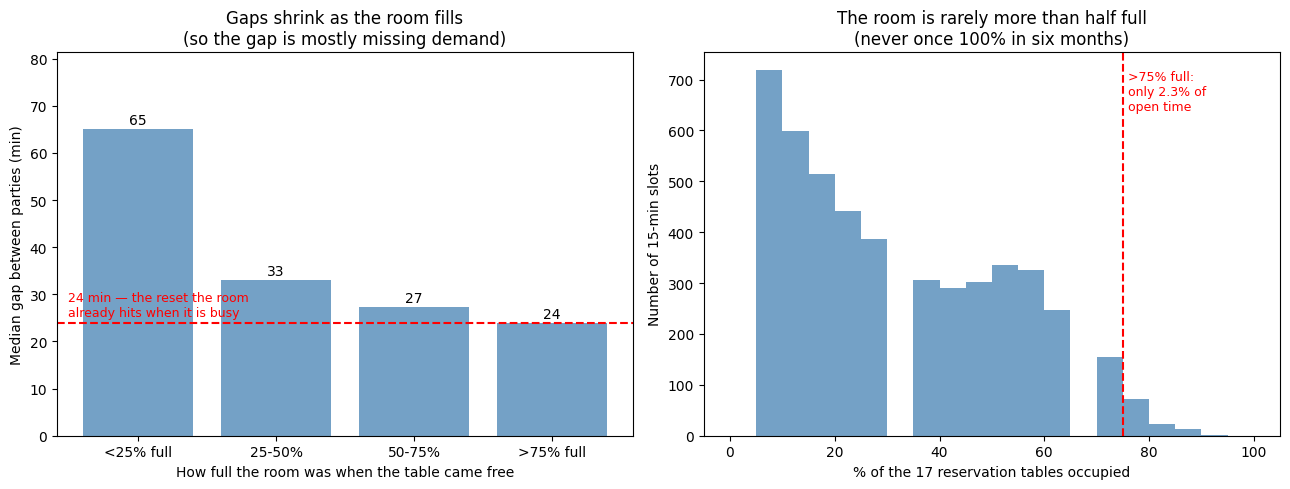

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: the decisive test. Gaps collapse as the room fills -- so most of the gap is absence of
# demand, not slow turning. The dashed line is the floor the room already achieves when busy.
bands = by_fullness.index.astype(str)
ax1.bar(bands, by_fullness['Median Gap'], color='steelblue', alpha=0.75)
ACHIEVABLE_RESET = by_fullness.loc['>75% full', 'Median Gap']
ax1.axhline(ACHIEVABLE_RESET, color='red', linestyle='--', linewidth=1.5)
ax1.text(0.02, ACHIEVABLE_RESET + 1.5, f'{ACHIEVABLE_RESET:.0f} min — the reset the room\nalready hits when it is busy',
         color='red', fontsize=9, transform=ax1.get_yaxis_transform())
for i, v in enumerate(by_fullness['Median Gap']):
    ax1.text(i, v + 1, f'{v:.0f}', ha='center', fontsize=10)
ax1.set_ylabel('Median gap between parties (min)')
ax1.set_xlabel('How full the room was when the table came free')
ax1.set_title('Gaps shrink as the room fills\n(so the gap is mostly missing demand)')
ax1.set_ylim(0, by_fullness['Median Gap'].max() * 1.25)

# Right: how often the room is anywhere near full. This is why the left chart's rightmost bar
# barely matters -- the bar almost never operates there.
ax2.hist(room['Room %'], bins=np.arange(0, 101, 5), color='steelblue', alpha=0.75)
ax2.axvline(75, color='red', linestyle='--', linewidth=1.5)
ax2.text(76, ax2.get_ylim()[1] * 0.85, f'>75% full:\nonly {100 * (room["Room %"] > 75).mean():.1f}% of\nopen time',
         color='red', fontsize=9)
ax2.set_xlabel('% of the 17 reservation tables occupied')
ax2.set_ylabel('Number of 15-min slots')
ax2.set_title('The room is rarely more than half full\n(never once 100% in six months)')

plt.tight_layout()
plt.show()

## What is faster turning actually worth?

Three ways to value the idle minutes, from most to least flattering. The difference between them is entirely about **whether a freed-up table has anyone to seat in it** — and that assumption is doing all the work.

In [23]:
# Blended revenue rate for a reservation-section table, used to price idle minutes.
blended_tpcpm = res['Amount'].sum() / (res['Duration'].sum() / 15)
ANNUALIZE = 2.0   # the export covers ~6 months of trading, so double it for an annual figure
peak_gaps = gaps[gaps['Paid_Hour'].between(17, 22)]

def price(idle_minutes):
    """Value idle table-minutes at the blended table rate, annualized."""
    return idle_minutes / 15 * blended_tpcpm * ANNUALIZE

scenarios = pd.DataFrame([
    {'Scenario': '1. Every freed minute sells (15-min reset target)',
     'Idle min': (peak_gaps['Turn_Gap'] - 15).clip(lower=0).sum(),
     'Assumes': 'a party is always waiting'},
    {'Scenario': f'2. Hit the {ACHIEVABLE_RESET:.0f}-min reset the room already achieves when busy',
     'Idle min': (peak_gaps['Turn_Gap'] - ACHIEVABLE_RESET).clip(lower=0).sum(),
     'Assumes': 'still that a party is always waiting'},
    {'Scenario': '3. Only gaps while the room was >75% full',
     'Idle min': (peak_gaps[peak_gaps['Room %'] > 75]['Turn_Gap'] - ACHIEVABLE_RESET).clip(lower=0).sum(),
     'Assumes': 'a party waits only when the room is nearly full'},
])
scenarios['Value ($/yr)'] = scenarios['Idle min'].map(price).round(0)
scenarios['Idle min'] = scenarios['Idle min'].round(0)

qualifying = (peak_gaps['Room %'] > 75).sum()
print(f'Blended table rate: ${blended_tpcpm:.2f} per table per 15 min')
print(f'Peak-window turns (5-11pm): {len(peak_gaps)}, of which only {qualifying} '
      f'({100 * qualifying / len(peak_gaps):.1f}%) happened while the room was >75% full\n')
scenarios[['Scenario', 'Idle min', 'Assumes', 'Value ($/yr)']]

Blended table rate: $21.42 per table per 15 min
Peak-window turns (5-11pm): 1619, of which only 141 (8.7%) happened while the room was >75% full



,Scenario,Idle min,Assumes,Value ($/yr)
0,1. Every freed minute sells (15-min reset target),54790.0,a party is always waiting,156465.0
1,2. Hit the 24-min reset the room already achie...,44578.0,still that a party is always waiting,127302.0
2,3. Only gaps while the room was >75% full,3301.0,a party waits only when the room is nearly full,9426.0


In [24]:
# Put turn gaps in proportion. Of all the table-time that went unsold while the doors were open,
# how much was "table empty between two parties" versus "table never got a party at all"?
#
# The denominator is generous -- it assumes every table could be occupied every minute from the
# night's first seating to its last payment, which no venue achieves. It is a denominator for
# comparing the two components against each other, not a revenue target.
night_span = res.groupby(['Service_Date', 'Service_DOW']).agg(
    first_seat=('Opened_DT', 'min'), last_paid=('Paid_DT', 'max'), occupied=('Duration', 'sum'))
night_span['available'] = ((night_span['last_paid'] - night_span['first_seat'])
                           .dt.total_seconds() / 60) * NT

available = night_span['available'].sum()
occupied = night_span['occupied'].sum()
unsold = available - occupied
gap_minutes = gaps['Turn_Gap'].sum()

print(f'While open, over {NIGHTS} nights:')
print(f'  table-minutes available : {available:>12,.0f}')
print(f'  actually occupied       : {occupied:>12,.0f}   ({100 * occupied / available:.1f}%)')
print(f'  unsold                  : {unsold:>12,.0f}   ({unsold / 60:,.0f} table-hours)')
print()
print(f'  of that unsold time, gaps between parties : {100 * gap_minutes / unsold:>5.1f}%')
print(f'  tables that never got a party that night  : {100 - 100 * gap_minutes / unsold:>5.1f}%')

utilization = (night_span.groupby('Service_DOW')
                 .agg(Nights=('available', 'count'), available=('available', 'sum'),
                      occupied=('occupied', 'sum')))
utilization['Utilization %'] = (100 * utilization['occupied'] / utilization['available']).round(1)
utilization['Unsold table-hr/night'] = ((utilization['available'] - utilization['occupied'])
                                        / utilization['Nights'] / 60).round(1)
print('\nBy day of week:')
utilization[['Nights', 'Utilization %', 'Unsold table-hr/night']].reindex(DOW_ORDER)

While open, over 153 nights:
  table-minutes available :    1,200,222
  actually occupied       :      346,768   (28.9%)
  unsold                  :      853,454   (14,224 table-hours)

  of that unsold time, gaps between parties :   9.4%
  tables that never got a party that night  :  90.6%

By day of week:


,Nights,Utilization %,Unsold table-hr/night
Service_DOW,,,
Tuesday,26,16.0,107.2
Wednesday,26,19.2,94.7
Thursday,26,25.7,89.9
Friday,26,41.8,88.0
Saturday,25,43.3,88.8
Sunday,23,19.6,90.3


## Party size: the economics are real, the seating fix is not

Larger parties are worth substantially more per minute of table time. The obvious operational conclusion — *stop seating 2-tops at tables that seat 4* — turns out not to survive contact with the utilization data, for the same reason turn times didn't. But a different and more interesting seating conclusion does.

In [25]:
single_table = res[~res['Likely_Combined_Booking']].copy()
single_table['TPCPM'] = single_table['Amount'] / (single_table['Duration'] / 15)

party_econ = single_table.groupby('# of Guests').agg(**{
    'Orders': ('Amount', 'count'),
    'Median Duration (min)': ('Duration', 'median'),
    'Median Check ($)': ('Amount', 'median'),
    'TPCPM ($)': ('TPCPM', lambda s: np.exp(np.log(s).mean())),
})
party_econ['$ per table-hour'] = (party_econ['TPCPM ($)'] * 4).round(0)
print('A bigger party earns far more per minute and barely stays longer:')
print(party_econ.round(1).to_string())

# Would steering 2-tops off larger tables actually free anything up? Only if a larger party was
# turned away for want of that table -- which requires the room to have been near-full.
single_table['Spare Seats'] = single_table['Capacity_Max'] - single_table['# of Guests']
oversized = single_table[single_table['Spare Seats'] >= 1].copy()
oversized['Slot'] = ((oversized['Opened_DT'] - oversized['Service_Date'])
                     .dt.total_seconds() / 60 // 15).astype(int)
oversized = oversized.merge(room[['Service_Date', 'Slot', 'Room %']],
                            on=['Service_Date', 'Slot'], how='left')
oversized['Room %'] = oversized['Room %'].fillna(0)

print(f'\nSeatings leaving >=1 seat unused: {len(oversized)} '
      f'({100 * len(oversized) / len(single_table):.1f}% of single-table seatings)')
print(f'  ...of which happened while the room was >75% full: {(oversized["Room %"] > 75).sum()}'
      f' ({100 * (oversized["Room %"] > 75).mean():.1f}%)')
print(f'  = {100 * (oversized["Room %"] > 75).sum() / len(single_table):.1f}% of all seatings could'
      ' conceivably have displaced a larger party.')

A bigger party earns far more per minute and barely stays longer:
             Orders  Median Duration (min)  Median Check ($)  TPCPM ($)  $ per table-hour
# of Guests                                                                              
1                31                   62.5              50.0        9.4              37.0
2              1879                   87.4              94.0       15.3              61.0
3               375                   93.5             118.0       18.1              72.0
4               647                  100.2             157.0       23.8              95.0
5               166                  104.2             194.5       27.6             110.0
6               191                  115.8             252.0       32.5             130.0
7                22                  116.1             241.5       31.6             126.0
8                59                  127.5             320.0       39.0             156.0

Seatings leaving >=1 seat unused:

Parties of 5+: 541 seatings (15.6% of all seatings) generating $149,240 = 30.1% of section revenue

Units seating 5+ without spanning units: {'BD 8-top banquette': 8, 'BD 6-top banquette': 6, 'E3 large': 6, 'O1+O2': 5, 'O7+O8': 5}
  = 30 of 46 reservation seats sit in units that can take a party of five or more.

Where large parties actually sat:
                    Seatings  Median Guests  Revenue ($)  Fits the unit  % fitting
Seating_Unit                                                                      
E3 large                 136            6.0      34466.0            128       94.0
BD 6-top banquette       134            6.0      38746.0            102       76.0
BD 8-top banquette       119            8.0      42471.0            103       87.0
O7+O8                     63            5.0      13066.0             53       84.0
O1+O2                     61            5.0      11811.0             52       85.0
E 2+2 pair                21            9.0       7752.0              

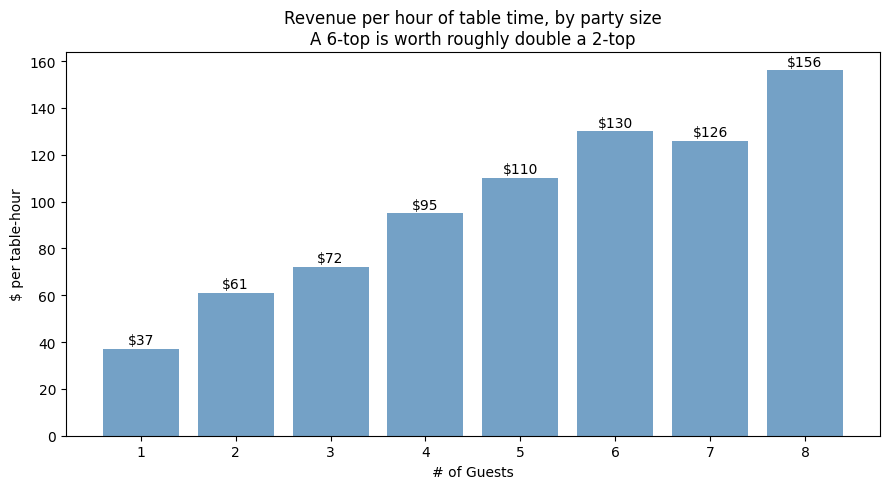

In [26]:
# CORRECTION. An earlier version of this cell claimed E3 was the only table in the building
# seating 5+, and that three quarters of large parties were therefore accommodated ad hoc. That
# was an artifact of the old per-code capacities, which modelled Black Duck as four small tables
# (11 seats) rather than a 6-seat and an 8-seat banquette (14 seats). Both Black Duck banquettes
# seat 5+ by design. The corrected picture is below.
big_parties = res[res['# of Guests'] >= 5].copy()

print(f'Parties of 5+: {len(big_parties)} seatings '
      f'({100 * len(big_parties) / len(res):.1f}% of all seatings) generating '
      f'${big_parties["Amount"].sum():,.0f} '
      f'= {100 * big_parties["Amount"].sum() / res["Amount"].sum():.1f}% of section revenue')

units_5plus = {u: spec['seats'] for u, spec in artemis.SEATING_UNITS.items()
               if spec['seats'] >= 5 and artemis.get_section(spec['tables'][0]) in artemis.RESERVATION_SECTIONS}
print(f'\nUnits seating 5+ without spanning units: {units_5plus}')
print(f'  = {sum(units_5plus.values())} of {sum(artemis.section_seats(s) for s in artemis.RESERVATION_SECTIONS)}'
      ' reservation seats sit in units that can take a party of five or more.')

print('\nWhere large parties actually sat:')
placement = (big_parties.groupby('Seating_Unit')
               .agg(**{'Seatings': ('Amount', 'count'),
                       'Median Guests': ('# of Guests', 'median'),
                       'Revenue ($)': ('Amount', 'sum'),
                       'Fits the unit': ('Likely_Combined_Booking', lambda s: (~s).sum())})
               .sort_values('Seatings', ascending=False))
placement['% fitting'] = (100 * placement['Fits the unit'] / placement['Seatings']).round(0)
print(placement.round(0).to_string())

fits = (~big_parties['Likely_Combined_Booking']).sum()
print(f'\n{fits} of {len(big_parties)} large parties ({100 * fits / len(big_parties):.0f}%) fit'
      ' entirely within a single physical unit.')
print('The floor plan serves this segment far better than the old capacity model suggested.')

fig, ax = plt.subplots(figsize=(9, 5))
sizes = party_econ.index
ax.bar(sizes, party_econ['$ per table-hour'], color='steelblue', alpha=0.75)
for s, v in zip(sizes, party_econ['$ per table-hour']):
    ax.text(s, v + 2, f'${v:.0f}', ha='center', fontsize=10)
ax.set_xlabel('# of Guests')
ax.set_ylabel('$ per table-hour')
ax.set_title('Revenue per hour of table time, by party size\n'
             'A 6-top is worth roughly double a 2-top')
ax.set_xticks(sizes)
plt.tight_layout()
plt.show()

In [27]:
# Is the decline in party count or party size? This matters: fewer parties is a demand problem,
# smaller parties is a mix problem, and they have different fixes.
res_monthly = res.copy()
res_monthly['Month'] = res_monthly['Service_Date'].dt.to_period('M')
trend = res_monthly.groupby('Month').agg(**{
    'Nights': ('Service_Date', 'nunique'),
    'Parties': ('Amount', 'count'),
    'Avg Party Size': ('# of Guests', 'mean'),
    'Revenue': ('Amount', 'sum'),
})
trend['Parties/night'] = (trend['Parties'] / trend['Nights']).round(1)
trend['Revenue/night'] = (trend['Revenue'] / trend['Nights']).round(0)

print('Jan/Jul are partial months (export starts 1/15 and ends 7/15).')
print(trend[['Nights', 'Parties/night', 'Avg Party Size', 'Revenue/night']].round(2).to_string())
print('\nParties per night is falling; average party size is not. The decline is footfall,')
print('not mix. Six months cannot separate that from seasonality -- revisit with a full year.')

Jan/Jul are partial months (export starts 1/15 and ends 7/15).
         Nights  Parties/night  Avg Party Size  Revenue/night
Month                                                        
2026-01      14           25.5            3.01         3856.0
2026-02      23           27.9            3.05         3995.0
2026-03      26           23.0            3.24         3335.0
2026-04      26           22.2            3.26         3143.0
2026-05      27           23.1            3.25         3174.0
2026-06      25           18.7            3.10         2551.0
2026-07      12           17.8            3.39         2615.0

Parties per night is falling; average party size is not. The decline is footfall,
not mix. Six months cannot separate that from seasonality -- revisit with a full year.


## What this section concludes

**The turn-time hypothesis is wrong, and that is the finding.** Idle time between parties looked like the big lever — a 30-minute median gap across 1,718 turns. It isn't:

- Gaps **collapse as the room fills**: 65 min when the room is under a quarter full, 24 min when it is over three quarters full. Lingering guests and slow bussing would not behave that way; absence of customers would.
- **No individual table is the problem.** Best to worst spans 13 minutes across 17 tables. There is no `BD3` to fix — its 296-minute Friday was one bad night, and its median gap is dead average.
- **The room never fills.** Zero 15-minute slots in six months had all 17 reservation tables occupied. Only 16 slots — four hours of trading out of roughly 1,200 — reached 15 of 17. Median utilization while open is 29%.
- Consequently the honest value of faster turning is about **$9K/yr**, not the $156K the naive calculation gives. The gap between those two numbers is entirely the assumption that a freed table has someone waiting for it.
- Turn gaps account for only **9.4%** of unsold table time. The other **90.6%** is tables that never got a party at all that night.

**Party-size steering fails the same test.** Larger parties genuinely are worth much more — $126 per table-hour for a 6-top against $61 for a 2-top, for only 27 extra minutes — but only 1.3% of seatings put a small party at a larger table while the room was busy enough for it to matter. There is nothing to reclaim.

**Retracted: the large-party floor-plan claim.** An earlier version of this section concluded that `E3` was the only unit seating 5+ and that three quarters of large parties were therefore seated ad hoc. That was an artifact of the old capacity model, which treated Black Duck as four small tables (11 seats) instead of a 6-seat and an 8-seat banquette (14 seats). Corrected: **81% of parties of 5+ fit entirely within a single physical unit**, and 30 of the 46 reservation seats sit in units that can take five or more. The floor plan serves this segment well. Large parties remain the most valuable per hour of table time — 15.6% of seatings, 30% of section revenue — but there is no layout problem to solve.

**And the trend needs watching.** Parties per night fell from ~26 in Jan/Feb to ~18 in Jun/Jul while average party size held steady. That is a footfall decline, not a mix shift. Six months cannot separate it from seasonality.

**Direction this points:** with both the turn-time and the floor-plan hypotheses closed out, the binding constraint is unambiguously **demand**. Effort spent turning tables faster, reshuffling party sizes, or redesigning the seating grid will return very little. What matters next is when the room is empty and why — the time-of-day work — and what is driving the decline in parties per night.